# 06b - CNN Review: Cats vs Dogs Classification

This notebook provides a hands-on review of CNNs by tackling a classic binary classification problem: distinguishing cats from dogs. You will apply concepts from previous notebooks (CNN architecture, pooling, regularization, and transfer learning) through a series of progressive exercises.

By the end of this notebook, you will have trained multiple models with increasing complexity and compared their performance on a real-world dataset.

## Table of Contents

1. [Setup and Dataset Loading](#Setup-and-Dataset-Loading)
2. [Exploring the tf.data API](#Exploring-the-tf.data-API)
3. [Exercise 1: Basic CNN without Pooling](#Exercise-1:-Basic-CNN-without-Pooling)
4. [Exercise 2: Adding Pooling Layers](#Exercise-2:-Adding-Pooling-Layers)
5. [Exercise 3: Regularization and Data Augmentation](#Exercise-3:-Regularization-and-Data-Augmentation)
6. [Exercise 4: Transfer Learning](#Exercise-4:-Transfer-Learning)
7. [Model Comparison](#Model-Comparison)
8. [Testing Generalization](#Testing-Generalization)
9. [Recap](#recap-cnn-review)

## Setup and Dataset Loading

We use the **Cats vs Dogs** dataset from TensorFlow Datasets, containing approximately 23,000 images of cats and dogs. This is a larger and more challenging dataset than the flowers dataset used previously.

In [75]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

%matplotlib inline

### Loading the Dataset

TensorFlow Datasets (`tfds`) provides a convenient way to load popular datasets. The `cats_vs_dogs` dataset contains labeled images of cats (0) and dogs (1).

In [76]:
# Load the cats_vs_dogs dataset
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)
dataset = dataset['train']

class_names = ['cat', 'dog']

# Count total images
total_images = tf.data.experimental.cardinality(dataset).numpy()
print(f'Total images: {total_images}')
print(f'Classes: {class_names}')

Total images: 23262
Classes: ['cat', 'dog']


### Image Preprocessing

The images in this dataset have varying sizes. We need to resize them to a consistent size for our CNN. We use 96×96 pixels for computational efficiency.

In [77]:
# Define image size and preprocessing function
IMAGE_SIZE = (96, 96)
INPUT_SHAPE = IMAGE_SIZE + (3,)  # 96x96x3 for RGB images

def preprocess_image(image, label):
    """Resize image to target size."""
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Apply preprocessing to all images
dataset = dataset.map(preprocess_image)

### Train/Validation/Test Split

We split the dataset into training (75%), validation (10%), and test (15%) sets.

In [78]:
BATCH_SIZE = 32

# Calculate split sizes
train_size = int(0.75 * total_images)
val_size = int(0.10 * total_images)

# Split the dataset
train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

# Configure for performance: shuffle, batch, cache, prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

print(f'Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}')
print(f'Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}')
print(f'Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}')

Training batches: 546
Validation batches: 73
Test batches: 110


### Visualizing Sample Images

2026-01-26 21:11:51.186897: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


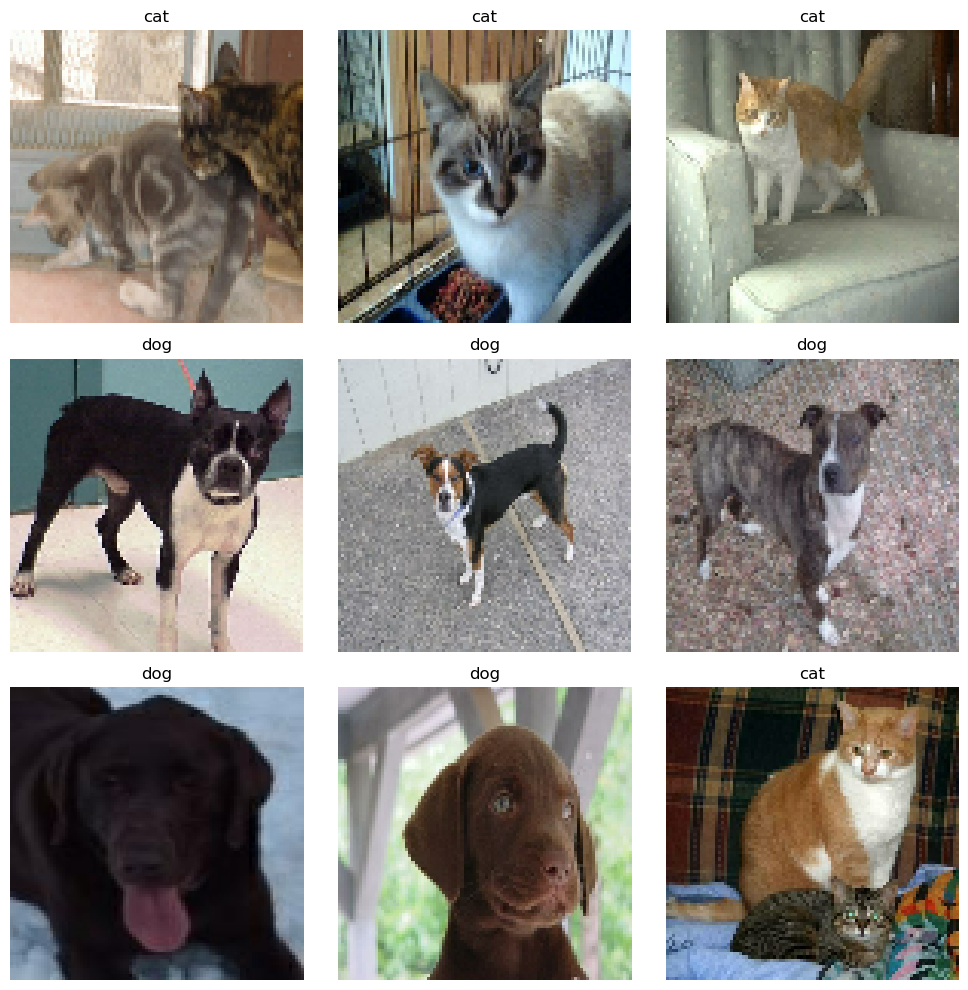

In [79]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

(Exploring-the-tf.data-API)=
## Exploring the tf.data API

The `tf.data.Dataset` API is TensorFlow's recommended way to create efficient input pipelines. It provides methods to load, transform, and batch data efficiently.

### Key Operations

- **`shuffle(buffer_size)`**: Randomly shuffles elements using a buffer
- **`batch(batch_size)`**: Combines consecutive elements into batches
- **`map(function)`**: Applies a transformation to each element
- **`cache()`**: Caches elements in memory after the first epoch
- **`prefetch(buffer_size)`**: Prepares next batches while current batch is being processed

In [80]:
# Quick demonstration of tf.data operations
demo_data = tf.data.Dataset.from_tensor_slices([1, 2, 3, 4, 5, 6, 7, 8])

# Shuffle with buffer_size=3
print("Original data:", list(demo_data.as_numpy_iterator()))

# Batch into groups of 2
batched = demo_data.batch(2)
print("\nBatched (size=2):")
for batch in batched:
    print(f"  {batch.numpy()}")

Original data: [1, 2, 3, 4, 5, 6, 7, 8]

Batched (size=2):
  [1 2]
  [3 4]
  [5 6]
  [7 8]


## Helper Functions

Let's define some utility functions we'll use throughout the exercises.

In [81]:
def plot_training_history(history, title='Training History'):
    """Plot training and validation metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Train Loss', marker='o')
    ax1.plot(history.history['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def show_errors(dataset, model, class_names, n_images=6):
    """Display misclassified images."""
    n_plots = 0
    plt.figure(figsize=(15, 5))
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = (predictions >= 0.5).astype(np.int32).flatten()
        
        # Find misclassified images
        wrong_indices = np.where(predicted_labels != labels.numpy())[0]
        
        for idx in wrong_indices:
            if n_plots >= n_images:
                plt.tight_layout()
                plt.show()
                return
            
            ax = plt.subplot(1, n_images, n_plots + 1)
            plt.imshow(images[idx].numpy().astype("uint8"))
            true_class = class_names[labels[idx].numpy()]
            pred_class = class_names[predicted_labels[idx]]
            prob = predictions[idx][0]
            plt.title(f'True: {true_class}\nPred: {pred_class} ({prob:.2f})', color='red')
            plt.axis('off')
            n_plots += 1
    
    plt.tight_layout()
    plt.show()

---

## Exercise 1: Basic CNN without Pooling

Build a simple CNN with **two convolutional layers** but **no pooling** and **no regularization**. This serves as a baseline to understand the importance of pooling layers.

### Architecture Requirements

1. Input layer: 96×96×3
2. Rescaling layer: normalize pixels to [0, 1]
3. Conv2D: 32 filters, 3×3 kernel, ReLU activation, 'same' padding
4. Conv2D: 64 filters, 3×3 kernel, ReLU activation, 'same' padding
5. Flatten
6. Dense: 64 units, ReLU activation
7. Output Dense: 1 unit, sigmoid activation (binary classification)

### Hints

- Use `keras.Input(shape=INPUT_SHAPE)` for the input layer
- Use `layers.Rescaling(1./255)` to normalize pixel values
- For binary classification, use `BinaryCrossentropy()` loss and sigmoid output
- The model will have many parameters due to no pooling

In [82]:
# TODO: Build a CNN with two Conv2D layers, no pooling

# inputs = keras.Input(shape=INPUT_SHAPE, name='input')

# Rescaling
# x = layers.Rescaling(...)(inputs)

# Conv Layer 1 (no pooling)
# x = layers.Conv2D(...)(x)

# Conv Layer 2 (no pooling)
# x = layers.Conv2D(...)(x)

# Classification head
# x = layers.Flatten()(x)
# x = layers.Dense(...)(x)
# outputs = layers.Dense(1, activation='sigmoid')(x)

# model_1 = keras.Model(inputs=inputs, outputs=outputs, name='cnn_no_pooling')

In [83]:
# TODO: Display model summary
# model_1.summary()

In [84]:
# TODO: Compile and train the model

# model_1.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.BinaryCrossentropy(),
#     metrics=['accuracy']
# )

# Use EarlyStopping to prevent overfitting
# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=2,
#     restore_best_weights=True
# )

# history_1 = model_1.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=8,
#     callbacks=[early_stopping]
# )

In [85]:
# TODO: Evaluate on test set
# results_1 = model_1.evaluate(test_ds, verbose=1)
# print(f'\nTest Loss: {results_1[0]:.4f}')
# print(f'Test Accuracy: {results_1[1]:.4f}')

In [86]:
# TODO: Plot training history
# plot_training_history(history_1, 'Model 1: No Pooling')

In [87]:
# TODO: Show some misclassified examples
# show_errors(test_ds, model_1, class_names)

### Observations

Without pooling layers:
- The model has **many parameters** (large Flatten → Dense connection)
- Training is slower and the model may struggle to generalize
- Feature maps maintain the original spatial dimensions

---

## Exercise 2: Adding Pooling Layers

Improve the previous model by adding **MaxPooling2D** layers after each convolution. This reduces spatial dimensions and the number of parameters.

### Architecture Requirements

1. Input layer: 96×96×3
2. Rescaling layer
3. Conv2D (32 filters) + MaxPooling2D(2×2)
4. Conv2D (64 filters) + MaxPooling2D(2×2)
5. Flatten
6. Dense (64 units)
7. Output Dense (1 unit, sigmoid)

### Hints

- Use `layers.MaxPooling2D(pool_size=(2, 2))` after each Conv2D
- Pooling reduces dimensions: 96 → 48 → 24
- Compare the number of parameters with Model 1

In [88]:
# TODO: Build a CNN with pooling after each Conv2D

# inputs = keras.Input(shape=INPUT_SHAPE, name='input')

# Rescaling
# x = layers.Rescaling(...)(inputs)

# Conv Layer 1 + Pooling
# x = layers.Conv2D(...)(x)
# x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Conv Layer 2 + Pooling
# x = layers.Conv2D(...)(x)
# x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Classification head
# x = layers.Flatten()(x)
# x = layers.Dense(...)(x)
# outputs = layers.Dense(1, activation='sigmoid')(x)

# model_2 = keras.Model(inputs=inputs, outputs=outputs, name='cnn_with_pooling')

In [89]:
# TODO: Display model summary and compare with model_1
# model_2.summary()

In [90]:
# TODO: Compile and train

# model_2.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.BinaryCrossentropy(),
#     metrics=['accuracy']
# )

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=2,
#     restore_best_weights=True
# )

# history_2 = model_2.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=8,
#     callbacks=[early_stopping]
# )

In [91]:
# TODO: Evaluate on test set
# results_2 = model_2.evaluate(test_ds, verbose=1)
# print(f'\nTest Loss: {results_2[0]:.4f}')
# print(f'Test Accuracy: {results_2[1]:.4f}')

In [92]:
# TODO: Plot training history
# plot_training_history(history_2, 'Model 2: With Pooling')

In [93]:
# TODO: Show some misclassified examples
# show_errors(test_ds, model_2, class_names)

### Observations

With pooling layers:
- **Fewer parameters** than Model 1 (smaller Flatten output)
- Better generalization due to reduced model complexity
- Spatial dimension reduction: 96 → 48 → 24

---

## Exercise 3: Regularization and Data Augmentation

Improve the model further by adding **regularization** (Dropout) and **data augmentation**. Your goal is to achieve **Test Accuracy > 0.80**.

### Architecture Requirements

1. Data augmentation (RandomFlip, RandomRotation)
2. At least 3 Conv2D + MaxPooling blocks
3. Dropout layers for regularization
4. Dense layers for classification

### Hints

- Use `layers.RandomFlip('horizontal')` and `layers.RandomRotation(0.2)` for augmentation
- Apply data augmentation at the beginning of the model
- Add `layers.Dropout(0.3)` or `layers.Dropout(0.5)` after Dense layers
- Consider adding more convolutional layers with increasing filters (32 → 64 → 128)
- You may need more epochs (10-15) for this model

In [94]:
# Data augmentation layers - applied only during training
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
], name='data_augmentation')

In [95]:
# TODO: Build a deeper CNN with augmentation and dropout

# inputs = keras.Input(shape=INPUT_SHAPE, name='input')

# Data augmentation (only active during training)
# x = data_augmentation(inputs)

# Rescaling
# x = layers.Rescaling(1./255)(x)

# Conv Block 1
# x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
# x = layers.MaxPooling2D((2, 2))(x)

# Conv Block 2
# x = layers.Conv2D(...)(x)
# x = layers.MaxPooling2D((2, 2))(x)

# Conv Block 3
# x = layers.Conv2D(...)(x)
# x = layers.MaxPooling2D((2, 2))(x)

# Classification head with Dropout
# x = layers.Flatten()(x)
# x = layers.Dense(...)(x)
# x = layers.Dropout(...)(x)
# outputs = layers.Dense(1, activation='sigmoid')(x)

# model_3 = keras.Model(inputs=inputs, outputs=outputs, name='cnn_with_regularization')

In [96]:
# TODO: Display model summary
# model_3.summary()

In [97]:
# TODO: Compile and train

# model_3.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.BinaryCrossentropy(),
#     metrics=['accuracy']
# )

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True
# )

# history_3 = model_3.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=15,
#     callbacks=[early_stopping]
# )

In [98]:
# TODO: Evaluate on test set - aim for > 0.80 accuracy
# results_3 = model_3.evaluate(test_ds, verbose=1)
# print(f'\nTest Loss: {results_3[0]:.4f}')
# print(f'Test Accuracy: {results_3[1]:.4f}')
# print(f'\nTarget achieved: {results_3[1] > 0.80}')

In [99]:
# TODO: Plot training history
# plot_training_history(history_3, 'Model 3: With Regularization')

In [100]:
# TODO: Show some misclassified examples
# show_errors(test_ds, model_3, class_names)

### Observations

With regularization and augmentation:
- **Reduced overfitting**: Smaller gap between train and validation accuracy
- **Better generalization**: Model sees augmented variations of each image
- Training may take longer but produces more robust models

---

## Exercise 4: Transfer Learning

Apply transfer learning using a pre-trained **MobileNetV2** backbone. This should achieve the best performance with the least training time.

### Architecture Requirements

1. Load MobileNetV2 with `include_top=False` and `weights='imagenet'`
2. Freeze the backbone (`trainable=False`)
3. Use the model's preprocessing function
4. Add GlobalAveragePooling2D and classification head

### Hints

- Use `tf.keras.applications.MobileNetV2` for the backbone
- Use `tf.keras.applications.mobilenet_v2.preprocess_input` for preprocessing
- Set `base_model.trainable = False` to freeze weights
- Use `GlobalAveragePooling2D` instead of `Flatten` for efficiency

In [101]:
# TODO: Load pre-trained MobileNetV2 (without top layer)

# base_model = tf.keras.applications.MobileNetV2(
#     input_shape=INPUT_SHAPE,
#     include_top=False,
#     weights='imagenet'
# )

# Freeze the backbone
# base_model.trainable = ...

# Get the preprocessing function
# preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [102]:
# TODO: Build transfer learning model

# inputs = keras.Input(shape=INPUT_SHAPE, name='input')

# Preprocessing for MobileNetV2
# x = preprocess_input(inputs)

# Pre-trained backbone (frozen)
# x = base_model(x, training=False)

# Classification head
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dropout(0.5)(x)
# outputs = layers.Dense(1, activation='sigmoid')(x)

# model_tl = keras.Model(inputs=inputs, outputs=outputs, name='transfer_learning')

In [103]:
# TODO: Display model summary
# model_tl.summary()

In [104]:
# TODO: Compile and train (only need a few epochs)

# model_tl.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.BinaryCrossentropy(),
#     metrics=['accuracy']
# )

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=2,
#     restore_best_weights=True
# )

# history_tl = model_tl.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=5,
#     callbacks=[early_stopping]
# )

In [105]:
# TODO: Evaluate on test set
# results_tl = model_tl.evaluate(test_ds, verbose=1)
# print(f'\nTest Loss: {results_tl[0]:.4f}')
# print(f'Test Accuracy: {results_tl[1]:.4f}')

In [106]:
# TODO: Plot training history
# plot_training_history(history_tl, 'Model TL: Transfer Learning')

In [107]:
# TODO: Show some misclassified examples
# show_errors(test_ds, model_tl, class_names)

### Observations

With transfer learning:
- **Best accuracy** with the least training time
- Pre-trained features from ImageNet transfer well to cats vs dogs
- Very few trainable parameters (only the classification head)

---

## Model Comparison

After completing all exercises, compare the performance of all models.

In [108]:
# TODO: Uncomment after completing all exercises

# print("=" * 60)
# print("MODEL COMPARISON")
# print("=" * 60)
# print(f"Model 1 (No Pooling):        Test Accuracy = {results_1[1]:.4f}")
# print(f"Model 2 (With Pooling):      Test Accuracy = {results_2[1]:.4f}")
# print(f"Model 3 (Regularization):    Test Accuracy = {results_3[1]:.4f}")
# print(f"Model TL (Transfer Learning): Test Accuracy = {results_tl[1]:.4f}")
# print("=" * 60)
# 
# # Find best model
# accuracies = {
#     'No Pooling': results_1[1],
#     'With Pooling': results_2[1],
#     'Regularization': results_3[1],
#     'Transfer Learning': results_tl[1]
# }
# best_model = max(accuracies, key=accuracies.get)
# print(f"\nBest performing model: {best_model}")

---

## Testing Generalization

Test how well your models generalize to new images. This section loads images from URLs and tests all models on them.

In [109]:
def predict_and_plot(image_path, models, model_names, class_names, image_size):
    """Load an image and predict with multiple models."""
    # Load and preprocess image
    image = tf.keras.preprocessing.image.load_img(image_path, target_size=image_size)
    image_array = tf.keras.preprocessing.image.img_to_array(image).astype(np.uint8)
    
    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image_array)
    plt.axis('off')
    plt.title('Test Image')
    plt.show()
    
    # Make predictions with each model
    print("\nPredictions:")
    print("-" * 50)
    
    for model, name in zip(models, model_names):
        # Expand dimensions for batch
        input_array = np.expand_dims(image_array, 0)
        
        # Predict
        prob = model.predict(input_array, verbose=0)[0][0]
        pred_class = class_names[int(prob >= 0.5)]
        
        print(f"{name}: {pred_class} (confidence: {prob:.2f})")

In [110]:
# TODO: Uncomment after completing all exercises to test generalization

# # Test image 1: A dog
# url_1 = 'https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg'
# image_path_1 = tf.keras.utils.get_file('test_dog.jpg', url_1)

# models = [model_1, model_2, model_3, model_tl]
# model_names = ['No Pooling', 'With Pooling', 'Regularization', 'Transfer Learning']

# predict_and_plot(image_path_1, models, model_names, class_names, IMAGE_SIZE)

In [111]:
# TODO: Uncomment to test with a cat image

# # Test image 2: A cat
# url_2 = 'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg'
# image_path_2 = tf.keras.utils.get_file('test_cat.jpg', url_2)

# predict_and_plot(image_path_2, models, model_names, class_names, IMAGE_SIZE)

---

## Recap

**Dataset and Preprocessing:**
- The `tf.data.Dataset` API provides efficient data loading with `shuffle`, `batch`, `cache`, and `prefetch`
- Images must be resized to consistent dimensions for CNN input
- Train/validation/test splits help evaluate model generalization

**CNN Architecture Evolution:**
- **Without pooling**: Too many parameters, poor generalization
- **With pooling**: Reduced parameters, better performance
- **With regularization**: Dropout and data augmentation reduce overfitting
- **Transfer learning**: Best results with least training time

**Key Techniques:**
- **MaxPooling2D**: Reduces spatial dimensions while preserving important features
- **Data augmentation**: Creates variations of training images (flips, rotations)
- **Dropout**: Randomly disables neurons during training to prevent overfitting
- **EarlyStopping**: Stops training when validation loss stops improving

**Transfer Learning:**
- Pre-trained models (MobileNetV2) provide excellent features for new tasks
- Freeze the backbone, train only the classification head
- Use the model's specific preprocessing function
- Achieves high accuracy with minimal training